<div style="font-family:Arial;">

<h1 style="color:#004aad; text-align:center; font-size:42px; margin-bottom:10px;">
  PROJET DE MACHINE LEARNING
</h1>

<div style="border:2px solid #b00000; padding:14px; border-radius:10px; text-align:center; width:80%; margin:auto;">
  <span style="font-size:34px; font-weight:bold; color:#7a0000;">
    HOUSE PRICES PREDICTION
  </span>
</div>

<h3 style="color:#004aad; text-align:center; font-size:35px; margin-bottom:10px;">
  FEATURE ENGINEERING & MODÉLISATION
</h3>

<p style="margin-top:25px; font-size:18px;">
  <b>Réalisé par :</b><br>
  • Compaoré BASSIROU<br>
  • Samba DIENG<br>
  • Yves Mistalengar DJERAKEI<br>
  • Divana KERENCIA<br>
  • Ange Emilson RAYAN<br>
</p>

<p style="margin-top:20px; font-size:15px; line-height:1.6;">
  <b>Objectif du notebook</b><br>
  Ce notebook présente un pipeline complet de Machine Learning pour prédire le prix des maisons (SalePrice) sur le dataset Ames Housing. Il inclut le feature engineering, le préprocessing, l'entraînement de multiples modèles avec et sans transformation de la variable cible, et l'évaluation des performances sur les valeurs réelles (en dollars).
</p>

<p style="margin-top:20px; font-size:16px; line-height:1.8; background-color:#f8f9fa; padding:15px; border-radius:8px; border-left:4px solid #004aad;">
  <b style="font-size:17px;">Plan du notebook</b><br><br>
  1. Chargement des données et compréhension rapide<br>
  2. Feature engineering (création de nouvelles variables)<br>
  3. Prétraitement et encodage des variables (numériques, ordinales, nominales)<br>
  4. Préparation de la variable cible et split train/test<br>
  5. Définition des métriques d'évaluation (priorité au MAE)<br>
  6. Entraînement des modèles avec et sans transformation de la cible<br>
  7. Optimisation des hyperparamètres via GridSearchCV<br>
  8. Comparaison globale des modèles et sélection du meilleur<br>
  9. Évaluation des performances sur valeurs réelles<br>
  10. Analyse des résidus et diagnostic du modèle<br>
  11. Interprétabilité : importance des variables<br>
  12. Analyse des erreurs de prédiction<br>
  13. Sauvegarde des modèles et génération des prédictions pour Kaggle
</p>

<p style="margin-top:15px; font-size:14px; line-height:1.6;">
  
<b>Méthodologie :</b><br>
- Feature engineering : création de nouvelles variables (âges, surfaces, équipements)<br>
- Préprocessing : utilisation de ColumnTransformer pour traiter différemment les variables numériques, ordinales et nominales<br>
- Modèles testés (8 modèles au total) :<br>
  • Modèles linéaires : LinearRegression, Ridge, Lasso, ElasticNet<br>
  • Modèles basés sur les arbres : RandomForest, GradientBoosting, LightGBM, XGBoost<br>
- Pour chaque modèle : deux versions sont entraînées (avec et sans transformation logarithmique de la cible) via TransformedTargetRegressor, soit 16 configurations au total<br>
- Optimisation : GridSearchCV avec validation croisée pour la sélection des hyperparamètres<br>
- Évaluation : métriques calculées sur les valeurs réelles (dollars) avec priorité au MAE<br>
- Sélection : comparaison globale de tous les modèles et sélection basée sur le MAE minimal

<b>Prérequis :</b> Exécuter `traitement.ipynb` et `exploration_base_donnees.ipynb`
</p>


</div>


In [1]:
# Importation des bibliothèques nécessaires
import time
import os
import joblib
from pathlib import Path
import sys

# Configuration du chemin du projet pour les imports
start_time = time.time()
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from src.feature_engineering import FeatureEngineer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, max_error
)

logging.basicConfig(level=logging.INFO)

In [2]:
# Charger les données après traitement des valeurs aberrantes
train_df = pd.read_csv("../data/processed/train_outliers_treat.csv", keep_default_na=False, na_filter=False)
test_df = pd.read_csv("../data/processed/test_outliers_treat.csv", keep_default_na=False, na_filter=False)

print("=" * 60)
print("CHARGEMENT DES DONNÉES (APRÈS TRAITEMENT DES OUTLIERS)")
print("=" * 60)
print(f"Données chargées: Train {train_df.shape}, Test {test_df.shape}")


CHARGEMENT DES DONNÉES (APRÈS TRAITEMENT DES OUTLIERS)
Données chargées: Train (1460, 82), Test (1459, 83)


In [3]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,HasGarage
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180968.421918,0.944521
std,421.610009,42.300571,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79448.240219,0.228992
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,0.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,1.000000
50%,730.500000,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,1.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,1.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,1.000000


In [4]:
# ============================================================
# ÉTAPE 1 : Feature Engineering - Variables d'âge et de surface
# ============================================================

def add_basic_features(df):
    """
    Crée de nouvelles variables dérivées à partir des variables existantes.
    
    Variables créées :
    - HouseAge : âge de la maison (année de vente - année de construction)
    - RemodAge : âge depuis la dernière rénovation
    - GarageAge : âge du garage
    - TotalSF : surface totale (sous-sol + premier étage + deuxième étage)
    - TotalPorchSF : surface totale des porches
    - TotalBath : nombre total de salles de bain (pondéré)
    """
    df = df.copy()

    # Calcul des âges (différence entre année de vente et année de construction/rénovation)
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

    # Calcul de l'âge du garage si la colonne existe
    if "GarageYrBlt" in df.columns:
        # Pour les maisons sans garage, GarageYrBlt peut être 0 ou NaN
        df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
    else:
        df["GarageAge"] = 0

    # Correction des valeurs négatives (les âges ne peuvent pas être négatifs)
    for col in ["HouseAge", "RemodAge", "GarageAge"]:
        if col in df.columns:
            df[col] = df[col].clip(lower=0)

    # Calcul de la surface totale (sous-sol + premier étage + deuxième étage)
    df["TotalSF"] = df.get("TotalBsmtSF", 0) + df.get("1stFlrSF", 0) + df.get("2ndFlrSF", 0)

    # Calcul de la surface totale des porches
    df["TotalPorchSF"] = (
        df.get("OpenPorchSF", 0)
        + df.get("EnclosedPorch", 0)
        + df.get("3SsnPorch", 0)
        + df.get("ScreenPorch", 0)
    )

    # Calcul du nombre total de salles de bain (pondéré : demi-salles comptent pour 0.5)
    df["TotalBath"] = (
        df.get("FullBath", 0)
        + 0.5 * df.get("HalfBath", 0)
        + df.get("BsmtFullBath", 0)
        + 0.5 * df.get("BsmtHalfBath", 0)
    )

    return df


# Application de la fonction de feature engineering sur les données d'entraînement et de test
train_df_fe = add_basic_features(train_df)
test_df_fe  = add_basic_features(test_df)

print("Dimensions des datasets après feature engineering:")
print("Train:", train_df.shape, "->", train_df_fe.shape)
print("Test :", test_df.shape, "->", test_df_fe.shape)

# Vérification de la qualité des nouvelles variables créées
check_cols = ["HouseAge", "RemodAge", "GarageAge", "TotalSF", "TotalPorchSF", "TotalBath"]
print("\nStatistiques descriptives des nouvelles variables (train):")
display(train_df_fe[check_cols].describe().T)

print("\nVérification des valeurs négatives (train):")
display((train_df_fe[check_cols] < 0).sum())


Dimensions des datasets après feature engineering:
Train: (1460, 82) -> (1460, 88)
Test : (1459, 83) -> (1459, 89)

Statistiques descriptives des nouvelles variables (train):


,count,mean,std,min,25%,50%,75%,max
HouseAge,1460.0,36.547945,30.250152,0.0,8.0,35.0,54.0,136.00
RemodAge,1460.0,22.950685,20.639875,0.0,4.0,14.0,41.0,60.00
GarageAge,1460.0,139.076027,453.714026,0.0,7.0,30.0,50.0,2010.00
TotalSF,1460.0,2561.450685,786.724834,334.0,2009.5,2474.0,3004.0,7797.05
TotalPorchSF,1460.0,87.084932,105.190364,0.0,0.0,48.0,136.0,1027.00
TotalBath,1460.0,2.210616,0.785399,1.0,2.0,2.0,2.5,6.00



Vérification des valeurs négatives (train):


HouseAge        0
RemodAge        0
GarageAge       0
TotalSF         0
TotalPorchSF    0
TotalBath       0
dtype: int64

La variable GarageAge présente une valeur maximale de 2010, ce qui est incohérent. Cela peut être dû au fait que certaines maisons n'ont pas de garage (GarageYrBlt = 0), ce qui donne GarageAge = YrSold - 0 = YrSold.

In [5]:
def fix_garage_age(df):
    df = df.copy()

    # 1) indicateur garage
    df["HasGarage"] = (df["GarageYrBlt"].fillna(0) > 0).astype(int)

    # 2) Age du garage (0 si pas de garage)
    df["GarageAge"] = np.where(
        df["HasGarage"] == 1,
        df["YrSold"] - df["GarageYrBlt"],
        0
    )

    # 3) sécurité
    df["GarageAge"] = df["GarageAge"].fillna(0).clip(lower=0)

    return df


train_df_fe = fix_garage_age(train_df_fe)
test_df_fe  = fix_garage_age(test_df_fe)

display(train_df_fe[["GarageYrBlt", "HasGarage", "GarageAge"]].describe())


,GarageYrBlt,HasGarage,GarageAge
count,1460.000000,1460.000000,1460.000000
mean,1868.739726,0.944521,27.680137
std,453.697295,0.228992,24.950144
min,0.000000,0.000000,0.000000
25%,1958.000000,1.000000,4.000000
50%,1977.000000,1.000000,23.500000
75%,2001.000000,1.000000,46.000000
max,2010.000000,1.000000,107.000000


In [6]:
ordinal_cols = [
    "LotShape","LandSlope",
    "ExterQual","ExterCond",
    "BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2",
    "HeatingQC","KitchenQual","Functional","FireplaceQu",
    "GarageFinish","GarageQual","GarageCond",
    "PoolQC","Fence"
]

def afficher_modalites(df, cols, dropna=False, tri=True):
    # Garde seulement les colonnes qui existent dans df
    cols_existantes = [c for c in cols if c in df.columns]
    cols_absentes = [c for c in cols if c not in df.columns]
    if cols_absentes:
        print("ATTENTION: Colonnes absentes du DataFrame :", cols_absentes)

    for c in cols_existantes:
        valeurs = df[c].unique() if not dropna else df[c].dropna().unique()
        valeurs = list(valeurs)

        if tri:
            # Tri “propre” même s'il y a des NaN / types mixtes
            valeurs = sorted(valeurs, key=lambda x: "" if pd.isna(x) else str(x))

        print(f"\n--- {c} ---")
        print(f"Nombre de modalités : {len(valeurs)}")
        print(valeurs)

# Exemple : sur train_df
afficher_modalites(train_df, ordinal_cols, dropna=False, tri=True)



--- LotShape ---
Nombre de modalités : 4
['IR1', 'IR2', 'IR3', 'Reg']

--- LandSlope ---
Nombre de modalités : 3
['Gtl', 'Mod', 'Sev']

--- ExterQual ---
Nombre de modalités : 4
['Ex', 'Fa', 'Gd', 'TA']

--- ExterCond ---
Nombre de modalités : 5
['Ex', 'Fa', 'Gd', 'Po', 'TA']

--- BsmtQual ---
Nombre de modalités : 5
['Ex', 'Fa', 'Gd', 'None', 'TA']

--- BsmtCond ---
Nombre de modalités : 5
['Fa', 'Gd', 'None', 'Po', 'TA']

--- BsmtExposure ---
Nombre de modalités : 5
['Av', 'Gd', 'Mn', 'No', 'None']

--- BsmtFinType1 ---
Nombre de modalités : 7
['ALQ', 'BLQ', 'GLQ', 'LwQ', 'None', 'Rec', 'Unf']

--- BsmtFinType2 ---
Nombre de modalités : 7
['ALQ', 'BLQ', 'GLQ', 'LwQ', 'None', 'Rec', 'Unf']

--- HeatingQC ---
Nombre de modalités : 5
['Ex', 'Fa', 'Gd', 'Po', 'TA']

--- KitchenQual ---
Nombre de modalités : 4
['Ex', 'Fa', 'Gd', 'TA']

--- Functional ---
Nombre de modalités : 7
['Maj1', 'Maj2', 'Min1', 'Min2', 'Mod', 'Sev', 'Typ']

--- FireplaceQu ---
Nombre de modalités : 6
['Ex', 'Fa',

In [7]:
afficher_modalites(test_df, ordinal_cols, dropna=False, tri=True)



--- LotShape ---
Nombre de modalités : 4
['IR1', 'IR2', 'IR3', 'Reg']

--- LandSlope ---
Nombre de modalités : 3
['Gtl', 'Mod', 'Sev']

--- ExterQual ---
Nombre de modalités : 4
['Ex', 'Fa', 'Gd', 'TA']

--- ExterCond ---
Nombre de modalités : 5
['Ex', 'Fa', 'Gd', 'Po', 'TA']

--- BsmtQual ---
Nombre de modalités : 5
['Ex', 'Fa', 'Gd', 'None', 'TA']

--- BsmtCond ---
Nombre de modalités : 5
['Fa', 'Gd', 'None', 'Po', 'TA']

--- BsmtExposure ---
Nombre de modalités : 5
['Av', 'Gd', 'Mn', 'No', 'None']

--- BsmtFinType1 ---
Nombre de modalités : 7
['ALQ', 'BLQ', 'GLQ', 'LwQ', 'None', 'Rec', 'Unf']

--- BsmtFinType2 ---
Nombre de modalités : 7
['ALQ', 'BLQ', 'GLQ', 'LwQ', 'None', 'Rec', 'Unf']

--- HeatingQC ---
Nombre de modalités : 5
['Ex', 'Fa', 'Gd', 'Po', 'TA']

--- KitchenQual ---
Nombre de modalités : 4
['Ex', 'Fa', 'Gd', 'TA']

--- Functional ---
Nombre de modalités : 7
['Maj1', 'Maj2', 'Min1', 'Min2', 'Mod', 'Sev', 'Typ']

--- FireplaceQu ---
Nombre de modalités : 6
['Ex', 'Fa',

In [8]:
# =========================================================
# 1) LISTES DE COLONNES (à adapter si besoin à ton dataset)
# =========================================================

ordinal_cols = [
    "LotShape", "LandSlope",
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "Functional", "FireplaceQu",
    "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence"
]

# Nominales (catégorielles NON ordonnées)
nominal_cols = [
    "MSSubClass", "MSZoning", "Street", "LandContour", "Utilities",
    "LotConfig", "Neighborhood", "Condition1", "Condition2",
    "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "Foundation", "Heating",
    "CentralAir", "Electrical",
    # Autres variables nominales possibles: Alley, GarageType, PavedDrive, SaleType, SaleCondition
]

# Variables numériques : détection automatique des colonnes restantes (hors target, ordinales, nominales)
def infer_numeric_cols(df, target_col=None, ordinal_cols=None, nominal_cols=None):
    exclude = set()
    if target_col is not None:
        exclude.add(target_col)
    if ordinal_cols is not None:
        exclude |= set(ordinal_cols)
    if nominal_cols is not None:
        exclude |= set(nominal_cols)

    # on garde uniquement les colonnes restantes
    remaining = [c for c in df.columns if c not in exclude]

    # parmi elles, on ne garde que celles qui sont numériques
    numeric = [c for c in remaining if pd.api.types.is_numeric_dtype(df[c])]
    return numeric


# =========================================================
# 2) ORDRES DES CATEGORIES ORDINALES (avec "None" en plus bas)
#    IMPORTANT : l'ordre doit correspondre EXACTEMENT à ordinal_cols
# =========================================================

# Ordre commun qualité/condition
qual_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

# LotShape (d'après la doc Ames)
lotshape_order = ["None", "IR3", "IR2", "IR1", "Reg"]

# LandSlope
landslope_order = ["None", "Gtl", "Mod", "Sev"]

# BsmtExposure
bsmtexpo_order = ["None", "No", "Mn", "Av", "Gd"]

# BsmtFinType (1/2)
bsmtfin_order = ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]

# Functional (d'après ta doc)
functional_order = ["None", "Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"]

# GarageFinish
garagefinish_order = ["None", "Unf", "RFn", "Fin"]

# Fence
fence_order = ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"]

# Les catégories ordinales dans le même ordre que ordinal_cols
ordinal_categories = [
    lotshape_order,          # LotShape
    landslope_order,         # LandSlope
    qual_order,              # ExterQual
    qual_order,              # ExterCond
    qual_order,              # BsmtQual
    qual_order,              # BsmtCond
    bsmtexpo_order,          # BsmtExposure
    bsmtfin_order,           # BsmtFinType1
    bsmtfin_order,           # BsmtFinType2
    qual_order,              # HeatingQC
    qual_order,              # KitchenQual
    functional_order,        # Functional
    qual_order,              # FireplaceQu
    garagefinish_order,      # GarageFinish
    qual_order,              # GarageQual
    qual_order,              # GarageCond
    qual_order,              # PoolQC
    fence_order              # Fence
]

# =========================================================
# 3) PIPELINES
# =========================================================

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    # On force "None" pour toutes les valeurs manquantes
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    # handle_unknown au cas où une modalité inattendue apparaît
    ("encoder", OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1))
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# =========================================================
# 4) PREPROCESSOR FINAL (ColumnTransformer)
# =========================================================

def build_preprocessor(train_df, target_col=None):
    num_cols = infer_numeric_cols(
        train_df, target_col=target_col,
        ordinal_cols=ordinal_cols, nominal_cols=nominal_cols
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, num_cols),
            ("ord", ordinal_pipeline, ordinal_cols),
            ("nom", nominal_pipeline, nominal_cols),
        ],
        remainder="drop"  # on drop le reste
    )
    return preprocessor, num_cols





In [9]:
# À la fin du notebook
end_time = time.time()
duration = end_time - start_time
print(f"Durée totale d'exécution : {duration:.2f} secondes")

Durée totale d'exécution : 5.18 secondes


Vérification


In [10]:
# =========================
# ML — ÉTAPE 0 : Preprocessor check (PROPRE)
# =========================


target_col = "SalePrice"

# 1) X / y depuis TRAIN (le seul qui a la cible)
X = train_df_fe.drop(columns=[target_col], errors="ignore")
y = train_df_fe[target_col].copy()

# 2) (pas de cible) -> on le garde séparé
X_kaggle = test_df_fe.copy()

# 3) Build preprocessor depuis la base FE train
preprocessor, numeric_cols = build_preprocessor(train_df_fe, target_col=target_col)

print("Shapes (raw):")
print("X (train features):", X.shape, "| y:", y.shape)
print("X_kaggle (test features):", X_kaggle.shape)
print("\nNb numeric cols détectées:", len(numeric_cols))

# 4) Test fit/transform (juste pour vérifier que ça marche)
Xt = preprocessor.fit_transform(X)
Xt_kaggle = preprocessor.transform(X_kaggle)

print("\nShapes transformed:")
print("Xt (train):", Xt.shape)
print("Xt_kaggle:", Xt_kaggle.shape)

# 5) Sanity NaN/Inf
Xt_np = np.asarray(Xt)
Xt_kaggle_np = np.asarray(Xt_kaggle)

print("\nNaN/Inf checks:")
print("NaN Xt:", np.isnan(Xt_np).sum(), "| Inf Xt:", np.isinf(Xt_np).sum())
print("NaN Xt_kaggle:", np.isnan(Xt_kaggle_np).sum(), "| Inf Xt_kaggle:", np.isinf(Xt_kaggle_np).sum())


Shapes (raw):
X (train features): (1460, 87) | y: (1460,)
X_kaggle (test features): (1459, 89)

Nb numeric cols détectées: 43

Shapes transformed:
Xt (train): (1460, 213)
Xt_kaggle: (1459, 213)

NaN/Inf checks:
NaN Xt: 0 | Inf Xt: 0
NaN Xt_kaggle: 0 | Inf Xt_kaggle: 0


In [11]:
# ============================================================
# ML — ÉTAPE 1 : split classique + y_raw + métriques sur valeurs réelles
# ============================================================

from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer

RANDOM_STATE = 42

# 1) Split TRAIN uniquement
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Split OK")
print("X_train:", X_train.shape, "| y_train:", y_train_raw.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test_raw.shape)

# Conservation des valeurs réelles pour l'entraînement
# TransformedTargetRegressor gère automatiquement la transformation logarithmique si nécessaire
y_train = y_train_raw.copy()
y_test = y_test_raw.copy()

print("\nValeurs réelles conservées (non transformées)")
print("y_train (min/max):", float(y_train.min()), "/", float(y_train.max()))
print("y_test  (min/max):", float(y_test.min()),  "/", float(y_test.max()))

# Définition de la fonction de calcul du RMSE
def rmse(y_true, y_pred):
    """
    Calcule la racine carrée de l'erreur quadratique moyenne.
    
    Parameters:
    -----------
    y_true : array-like
        Valeurs réelles observées
    y_pred : array-like
        Valeurs prédites par le modèle
        
    Returns:
    --------
    float
        RMSE calculé
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Définition de la fonction de calcul de toutes les métriques de performance
def get_all_performances(value_train: tuple, values_test: tuple, metrics: list) -> pd.DataFrame:
    """
    Calcule toutes les métriques de performance sur les ensembles d'entraînement et de test.
    
    Parameters:
    -----------
    value_train : tuple
        (y_train, y_train_pred) - valeurs réelles et prédites pour l'entraînement
    values_test : tuple
        (y_test, y_test_pred) - valeurs réelles et prédites pour le test
    metrics : list
        Liste des fonctions de métriques à calculer
        
    Returns:
    --------
    pd.DataFrame
        DataFrame contenant les métriques calculées pour train et test
    """
    test_perfs, train_perfs, metric_names = [], [], []
    for metric_func in metrics:
        metric_names.append(metric_func.__name__)
        train_perfs.append(metric_func(*value_train))
        test_perfs.append(metric_func(*values_test))
    return pd.DataFrame({"metric": metric_names, "train": train_perfs, "test": test_perfs})

# Définition des métriques d'évaluation sur valeurs réelles
# Le MAE est privilégié car il est moins sensible aux valeurs aberrantes que le RMSE
METRICS_REAL = [r2_score, mean_squared_error, rmse, mean_absolute_error, mean_absolute_percentage_error, max_error]

print("\nMétriques définies:", [m.__name__ for m in METRICS_REAL])
print("Métrique principale: MAE (moins sensible aux valeurs aberrantes que RMSE)")


Split OK
X_train: (1168, 87) | y_train: (1168,)
X_test : (292, 87) | y_test : (292,)

Valeurs réelles conservées (non transformées)
y_train (min/max): 34900.0 / 745000.0
y_test  (min/max): 35311.0 / 755000.0

Métriques définies: ['r2_score', 'mean_squared_error', 'rmse', 'mean_absolute_error', 'mean_absolute_percentage_error', 'max_error']
Métrique principale: MAE (moins sensible aux valeurs aberrantes que RMSE)


In [12]:
# On récupère uniquement la partie ordinale en la transformant séparément
ord_pipe = ordinal_pipeline
ord_train = ord_pipe.fit_transform(X_train[ordinal_cols])
ord_test  = ord_pipe.transform(X_test[ordinal_cols])

ord_train_np = np.asarray(ord_train)
ord_test_np  = np.asarray(ord_test)

pct_unknown_train = (ord_train_np == -1).mean() * 100
pct_unknown_test  = (ord_test_np == -1).mean() * 100

print(f"% unknown (-1) ordinals - train: {pct_unknown_train:.4f}%")
print(f"% unknown (-1) ordinals - test : {pct_unknown_test:.4f}%")


% unknown (-1) ordinals - train: 0.0000%
% unknown (-1) ordinals - test : 0.0000%


In [13]:
# =========================
#  CHECK proportion de -1 (unknown) dans les ordinals
# =========================
# On récupère uniquement la partie ordinale en la transformant séparément
ord_pipe = ordinal_pipeline
ord_train = ord_pipe.fit_transform(X_train[ordinal_cols])
ord_test  = ord_pipe.transform(X_test[ordinal_cols])

ord_train_np = np.asarray(ord_train)
ord_test_np  = np.asarray(ord_test)

pct_unknown_train = (ord_train_np == -1).mean() * 100
pct_unknown_test  = (ord_test_np == -1).mean() * 100

print(f"% unknown (-1) ordinals - train: {pct_unknown_train:.4f}%")
print(f"% unknown (-1) ordinals - test : {pct_unknown_test:.4f}%")


% unknown (-1) ordinals - train: 0.0000%
% unknown (-1) ordinals - test : 0.0000%


In [14]:
# ============================================================
# ML — ÉTAPE 2 : Baseline DummyRegressor (pipeline + timing)
# ============================================================

from sklearn.dummy import DummyRegressor

# Pipeline (on garde TON preprocessor)
dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

t0 = time.time()
dummy_pipe.fit(X_train, y_train)   # y_train est en valeurs réelles
fit_time = time.time() - t0

# Prédictions (en valeurs réelles)
yhat_train = dummy_pipe.predict(X_train)
yhat_test  = dummy_pipe.predict(X_test)

# Performances sur valeurs réelles
perfs_dummy = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

print(f"Dummy fit_time: {fit_time:.3f} sec")
perfs_dummy


Dummy fit_time: 0.096 sec


,metric,train,test
0,r2_score,-4.563962e-02,-2.497161e-02
1,mean_squared_error,6.237896e+09,7.861867e+09
2,rmse,7.898035e+04,8.866717e+04
3,mean_absolute_error,5.459863e+04,5.956825e+04
4,mean_absolute_percentage_error,3.116941e-01,3.597430e-01
5,max_error,5.800000e+05,5.900000e+05


In [15]:
# ============================================================
# ML — ÉTAPE 3 : Ridge + GridSearchCV avec TransformedTargetRegressor
# ============================================================
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


# 1) Pipeline Ridge (sans transformation de la cible)
ridge_base_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

# Encapsulation avec TransformedTargetRegressor pour gérer automatiquement la transformation logarithmique
ridge_pipe = TransformedTargetRegressor(
    regressor=ridge_base_pipe,
    func=np.log1p,  # Transformation logarithmique avant l'entraînement
    inverse_func=np.expm1  # Transformation inverse pour obtenir les prédictions en valeurs réelles
)

# Définition de la grille de recherche des hyperparamètres
ridge_param_grid = {
    "regressor__model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
}

# Optimisation des hyperparamètres via GridSearchCV
# Le scoring est basé sur le MAE (moins sensible aux valeurs aberrantes que le RMSE)
ridge_gs = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

# Entraînement du modèle avec optimisation des hyperparamètres
t0 = time.time()
ridge_gs.fit(X_train, y_train)  # y_train contient les valeurs réelles
fit_time = time.time() - t0

best_ridge = ridge_gs.best_estimator_
best_params = ridge_gs.best_params_

print("Temps d'entraînement Ridge (GridSearch):", round(fit_time, 3), "secondes")
print("Meilleurs hyperparamètres:", best_params)

# Calcul des prédictions (automatiquement en valeurs réelles grâce à TransformedTargetRegressor)
yhat_train = best_ridge.predict(X_train)
yhat_test  = best_ridge.predict(X_test)

# Calcul des performances sur les valeurs réelles
perfs_ridge = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

perfs_ridge


Temps d'entraînement Ridge (GridSearch): 8.532 secondes
Meilleurs hyperparamètres: {'regressor__model__alpha': 2.0}


,metric,train,test
0,r2_score,9.351051e-01,9.308386e-01
1,mean_squared_error,3.871386e+08,5.304908e+08
2,rmse,1.967584e+04,2.303239e+04
3,mean_absolute_error,1.231327e+04,1.496795e+04
4,mean_absolute_percentage_error,6.992862e-02,8.957868e-02
5,max_error,2.212773e+05,1.200847e+05


In [17]:
# ============================================================
# ML — ÉTAPE 4 : Lasso (régression linéaire avec sélection)
# ============================================================
from sklearn.linear_model import Lasso


# Pipeline Lasso : même preprocessing, seul le modèle change
lasso_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Lasso(max_iter=50000))
])

# Grille de valeurs pour le paramètre de régularisation
# (valeurs faibles à modérées pour éviter un modèle trop agressif)
lasso_param_grid = {
    "model__alpha": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
}

lasso_gs = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

t0 = time.time()
lasso_gs.fit(X_train, y_train)
fit_time = time.time() - t0

best_lasso = lasso_gs.best_estimator_
best_params = lasso_gs.best_params_

print("Lasso GridSearch fit_time:", round(fit_time, 3), "sec")
print("Best params:", best_params)

# Prédictions (toujours sur l’échelle log)
yhat_train = best_lasso.predict(X_train)
yhat_test  = best_lasso.predict(X_test)

# Performances sur valeurs réelles
perfs_lasso = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

perfs_lasso


Lasso GridSearch fit_time: 467.969 sec
Best params: {'model__alpha': 0.1}


C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.700e+11, tolerance: 6.968e+08
  model = cd_fast.enet_coordinate_descent(


,metric,train,test
0,r2_score,9.191258e-01,8.807605e-01
1,mean_squared_error,4.824656e+08,9.146055e+08
2,rmse,2.196510e+04,3.024245e+04
3,mean_absolute_error,1.501103e+04,1.949752e+04
4,mean_absolute_percentage_error,8.928073e-02,1.169570e-01
5,max_error,1.687206e+05,1.980148e+05


In [20]:
# ============================================================
# ML — ÉTAPE 5 : ElasticNet (combinaison Lasso et Ridge)
# ============================================================
from sklearn.linear_model import ElasticNet

# Construction du pipeline ElasticNet avec le même préprocessing
# ElasticNet combine les régularisations L1 (Lasso) et L2 (Ridge)
elastic_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ElasticNet(max_iter=50000))
])

# Définition de la grille de recherche des hyperparamètres
# alpha : intensité de la régularisation
# l1_ratio : compromis entre Lasso (1.0) et Ridge (0.0)
elastic_param_grid = {
    "model__alpha": [1e-3, 5e-3, 1e-2, 5e-2, 1e-1],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

# Optimisation des hyperparamètres via GridSearchCV
elastic_gs = GridSearchCV(
    estimator=elastic_pipe,
    param_grid=elastic_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

# Entraînement du modèle avec optimisation des hyperparamètres
t0 = time.time()
elastic_gs.fit(X_train, y_train)
elastic_time = time.time() - t0

best_elastic = elastic_gs.best_estimator_

print("Temps d'entraînement ElasticNet (GridSearch):", round(elastic_time, 3), "secondes")
print("Meilleurs hyperparamètres:", elastic_gs.best_params_)

# Calcul des prédictions (en valeurs réelles)
yhat_train = best_elastic.predict(X_train)
yhat_test  = best_elastic.predict(X_test)

# Calcul des performances sur les valeurs réelles
perfs_elastic = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

perfs_elastic


Temps d'entraînement ElasticNet (GridSearch): 186.743 secondes
Meilleurs hyperparamètres: {'model__alpha': 0.01, 'model__l1_ratio': 0.5}


,metric,train,test
0,r2_score,9.066248e-01,8.762699e-01
1,mean_squared_error,5.570415e+08,9.490504e+08
2,rmse,2.360173e+04,3.080666e+04
3,mean_absolute_error,1.574525e+04,1.885200e+04
4,mean_absolute_percentage_error,9.273712e-02,1.129143e-01
5,max_error,1.953724e+05,2.338465e+05


In [21]:
# ============================================================
# ML — ÉTAPE 6 : Random Forest (ensemble d'arbres de décision)
# ============================================================
from sklearn.ensemble import RandomForestRegressor

# Construction du pipeline Random Forest avec le même préprocessing
# Random Forest combine plusieurs arbres de décision pour améliorer la robustesse
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Définition de la grille de recherche des hyperparamètres
rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 5]
}

# Optimisation des hyperparamètres via GridSearchCV
# Réduction du nombre de folds pour limiter le temps d'exécution
rf_gs = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

# Entraînement du modèle avec optimisation des hyperparamètres
t0 = time.time()
rf_gs.fit(X_train, y_train)
rf_time = time.time() - t0

best_rf = rf_gs.best_estimator_

print("Temps d'entraînement Random Forest (GridSearch):", round(rf_time, 3), "secondes")
print("Meilleurs hyperparamètres:", rf_gs.best_params_)

# Calcul des prédictions (en valeurs réelles)
yhat_train = best_rf.predict(X_train)
yhat_test  = best_rf.predict(X_test)

# Calcul des performances sur les valeurs réelles
perfs_rf = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

perfs_rf


Temps d'entraînement Random Forest (GridSearch): 99.17 secondes
Meilleurs hyperparamètres: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


,metric,train,test
0,r2_score,9.806397e-01,8.905663e-01
1,mean_squared_error,1.154966e+08,8.393923e+08
2,rmse,1.074693e+04,2.897227e+04
3,mean_absolute_error,6.195680e+03,1.721556e+04
4,mean_absolute_percentage_error,3.615397e-02,1.044035e-01
5,max_error,1.181181e+05,1.889681e+05


In [22]:
# ============================================================
# ML — ÉTAPE 7 : Gradient Boosting Regressor (boosting séquentiel)
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor

# Construction du pipeline Gradient Boosting avec le même préprocessing
# Gradient Boosting construit séquentiellement des arbres pour corriger les erreurs précédentes
gbr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Définition de la grille de recherche des hyperparamètres
gbr_param_grid = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__subsample": [0.8, 1.0]
}

# Optimisation des hyperparamètres via GridSearchCV
gbr_gs = GridSearchCV(
    estimator=gbr_pipe,
    param_grid=gbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

# Entraînement du modèle avec optimisation des hyperparamètres
gbr_gs.fit(X_train, y_train)

best_gbr = gbr_gs.best_estimator_

print("Meilleurs hyperparamètres:", gbr_gs.best_params_)

# Calcul des prédictions (en valeurs réelles)
yhat_train = best_gbr.predict(X_train)
yhat_test  = best_gbr.predict(X_test)

# Calcul des performances sur les valeurs réelles
perfs_gbr = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

perfs_gbr


Meilleurs hyperparamètres: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.8}


,metric,train,test
0,r2_score,9.854164e-01,9.093555e-01
1,mean_squared_error,8.700015e+07,6.952729e+08
2,rmse,9.327387e+03,2.636803e+04
3,mean_absolute_error,7.221040e+03,1.528705e+04
4,mean_absolute_percentage_error,4.559102e-02,9.020288e-02
5,max_error,5.941847e+04,1.693402e+05


In [23]:
# ============================================================
# ML — ÉTAPE 8 : LightGBM (gradient boosting optimisé)
# ============================================================
import lightgbm as lgb
import time
import warnings

# Suppression des warnings LightGBM
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# Construction du pipeline LightGBM avec le même préprocessing
# LightGBM est une implémentation optimisée du gradient boosting, plus rapide et efficace
lgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", lgb.LGBMRegressor(
        objective="regression",
        random_state=42,
        verbosity=-1  # Désactive les messages de LightGBM
    ))
])

# Définition de la grille de recherche des hyperparamètres
lgb_param_grid = {
    "model__n_estimators": [500, 1000],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [-1, 6, 8],
    "model__num_leaves": [31, 63],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

# Optimisation des hyperparamètres via GridSearchCV
lgb_gs = GridSearchCV(
    estimator=lgb_pipe,
    param_grid=lgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

# Entraînement du modèle avec optimisation des hyperparamètres
t0 = time.time()
lgb_gs.fit(X_train, y_train)
lgb_time = time.time() - t0

best_lgb = lgb_gs.best_estimator_

print("Meilleurs hyperparamètres:", lgb_gs.best_params_)
print("Temps d'entraînement:", round(lgb_time, 3), "secondes")

# Calcul des prédictions (en valeurs réelles)
yhat_train = best_lgb.predict(X_train)
yhat_test  = best_lgb.predict(X_test)

# Calcul des performances sur les valeurs réelles
perfs_lgb = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

perfs_lgb


Meilleurs hyperparamètres: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__n_estimators': 1000, 'model__num_leaves': 31, 'model__subsample': 0.8}
Temps d'entraînement: 47.91 secondes


C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,metric,train,test
0,r2_score,9.929324e-01,8.886111e-01
1,mean_squared_error,4.216271e+07,8.543895e+08
2,rmse,6.493282e+03,2.922994e+04
3,mean_absolute_error,4.495844e+03,1.686412e+04
4,mean_absolute_percentage_error,2.909047e-02,9.928427e-02
5,max_error,6.103894e+04,2.035985e+05


Le modèle LightGBM présente d’excellentes performances sur l’échantillon
d’entraînement, avec un R² proche de 1. Cependant, la performance sur l’échantillon
de test est inférieure à celle obtenue avec les modèles linéaires régularisés.
Cela suggère un phénomène de sur-apprentissage : le gain de complexité du modèle
ne se traduit pas par une meilleure capacité de généralisation.


In [25]:
from xgboost import XGBRegressor
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])


# =========================
# 2) Grille d'hyperparamètres (raisonnable)
# =========================

xgb_param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.1],
    "model__reg_lambda": [1.0, 5.0]
}


# =========================
# 3) GridSearch (sur RMSE en CV, sur y_log)
# =========================

xgb_gs = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

t0 = time.time()
xgb_gs.fit(X_train, y_train)  # y_train est en valeurs réelles
fit_time = time.time() - t0


# =========================
# 4) Évaluation finale sur split (train/test) — valeurs réelles
# =========================

best_xgb = xgb_gs.best_estimator_

yhat_tr = best_xgb.predict(X_train)
yhat_te = best_xgb.predict(X_test)

print(f"\nXGBoost GridSearch fit_time: {fit_time:.3f} sec")
print("Best params:", xgb_gs.best_params_)

xgb_perf =  get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_REAL
)

display(xgb_perf)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

XGBoost GridSearch fit_time: 708.610 sec
Best params: {'model__colsample_bytree': 0.6, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 600, 'model__reg_alpha': 0.1, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}


,metric,train,test
0,r2_score,9.929324e-01,8.886111e-01
1,mean_squared_error,4.216271e+07,8.543895e+08
2,rmse,6.493282e+03,2.922994e+04
3,mean_absolute_error,4.495844e+03,1.686412e+04
4,mean_absolute_percentage_error,2.909047e-02,9.928427e-02
5,max_error,6.103894e+04,2.035985e+05


In [26]:
# ============================================================
# ML — ÉTAPE 9 : Tous les modèles avec et sans transformation
# ============================================================
# Cette section crée pour CHAQUE modèle deux versions :
# 1. Avec TransformedTargetRegressor (transformation log)
# 2. Sans transformation (valeurs réelles directes)
# Puis compare toutes les approches sur les valeurs réelles

print("="*80)
print("CRÉATION DE TOUS LES MODÈLES AVEC ET SANS TRANSFORMATION")
print("="*80)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
import warnings

# Suppression des warnings LightGBM
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# Fonction helper pour entraîner un modèle avec et sans transformation
def train_model_with_and_without_transform(
    model_name, base_model, param_grid_with, param_grid_without, 
    cv_folds=3, scoring="neg_mean_absolute_error"
):
    """
    Entraîne un modèle avec et sans transformation
    
    Returns:
        dict avec 'with_transform', 'without_transform', 'perfs_with', 'perfs_without'
    """
    print(f"\n{'='*60}")
    print(f"MODÈLE: {model_name}")
    print(f"{'='*60}")
    
    # =========================
    # Version AVEC transformation
    # =========================
    base_pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", base_model)
    ])
    
    model_with_transform = TransformedTargetRegressor(
        regressor=base_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    # Si pas de paramètres à tuner, utiliser directement le modèle
    if param_grid_with:
        gs_with = GridSearchCV(
            estimator=model_with_transform,
            param_grid=param_grid_with,
            scoring=scoring,
            cv=cv_folds,
            n_jobs=-1
        )
        print(f"\n[{model_name}] Entraînement AVEC transformation (GridSearch)...")
        t0 = time.time()
        gs_with.fit(X_train, y_train)
        fit_time_with = time.time() - t0
        best_with = gs_with.best_estimator_
        best_params_with = gs_with.best_params_
    else:
        print(f"\n[{model_name}] Entraînement AVEC transformation (sans tuning)...")
        t0 = time.time()
        model_with_transform.fit(X_train, y_train)
        fit_time_with = time.time() - t0
        best_with = model_with_transform
        best_params_with = {}
        gs_with = None
    yhat_train_with = best_with.predict(X_train)
    yhat_test_with = best_with.predict(X_test)
    
    perfs_with = get_all_performances(
        value_train=(y_train, yhat_train_with),
        values_test=(y_test, yhat_test_with),
        metrics=METRICS_REAL
    )
    perfs_with["model"] = f"{model_name}_WithTransform"
    
    print(f"Temps: {fit_time_with:.2f} sec | Best params: {best_params_with}")
    mae_with = perfs_with[perfs_with["metric"] == "mean_absolute_error"]["test"].values[0]
    print(f"MAE (test) = ${mae_with:,.2f}")
    
    # =========================
    # Version SANS transformation
    # =========================
    model_without_transform = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", base_model)
    ])
    
    # Si pas de paramètres à tuner, utiliser directement le modèle
    if param_grid_without:
        gs_without = GridSearchCV(
            estimator=model_without_transform,
            param_grid=param_grid_without,
            scoring=scoring,
            cv=cv_folds,
            n_jobs=-1
        )
        print(f"\n[{model_name}] Entraînement SANS transformation (GridSearch)...")
        t0 = time.time()
        gs_without.fit(X_train, y_train)
        fit_time_without = time.time() - t0
        best_without = gs_without.best_estimator_
        best_params_without = gs_without.best_params_
    else:
        print(f"\n[{model_name}] Entraînement SANS transformation (sans tuning)...")
        t0 = time.time()
        model_without_transform.fit(X_train, y_train)
        fit_time_without = time.time() - t0
        best_without = model_without_transform
        best_params_without = {}
        gs_without = None
    yhat_train_without = best_without.predict(X_train)
    yhat_test_without = best_without.predict(X_test)
    
    perfs_without = get_all_performances(
        value_train=(y_train, yhat_train_without),
        values_test=(y_test, yhat_test_without),
        metrics=METRICS_REAL
    )
    perfs_without["model"] = f"{model_name}_NoTransform"
    
    print(f"Temps: {fit_time_without:.2f} sec | Best params: {best_params_without}")
    mae_without = perfs_without[perfs_without["metric"] == "mean_absolute_error"]["test"].values[0]
    print(f"MAE (test) = ${mae_without:,.2f}")
    
    # Comparaison
    if mae_with < mae_without:
        print(f"{model_name}: AVEC transformation est meilleur (MAE: ${mae_with:,.2f} vs ${mae_without:,.2f})")
    else:
        print(f"{model_name}: SANS transformation est meilleur (MAE: ${mae_without:,.2f} vs ${mae_with:,.2f})")
    
    return {
        'with_transform': best_with,
        'without_transform': best_without,
        'perfs_with': perfs_with,
        'perfs_without': perfs_without,
        'gs_with': gs_with,
        'gs_without': gs_without
    }

# =========================
# 1) Linear Regression
# =========================
linear_results = train_model_with_and_without_transform(
    "LinearRegression",
    LinearRegression(),
    param_grid_with={},  # Pas de paramètres à tuner
    param_grid_without={}
)

# =========================
# 2) Ridge
# =========================
ridge_results = train_model_with_and_without_transform(
    "Ridge",
    Ridge(),
    param_grid_with={"regressor__model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]},
    param_grid_without={"model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]}
)

# =========================
# 3) Lasso
# =========================
lasso_results = train_model_with_and_without_transform(
    "Lasso",
    Lasso(max_iter=50000),
    param_grid_with={"regressor__model__alpha": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]},
    param_grid_without={"model__alpha": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]}
)

# =========================
# 4) ElasticNet
# =========================
elastic_results = train_model_with_and_without_transform(
    "ElasticNet",
    ElasticNet(max_iter=50000),
    param_grid_with={
        "regressor__model__alpha": [1e-3, 5e-3, 1e-2, 5e-2, 1e-1],
        "regressor__model__l1_ratio": [0.2, 0.5, 0.8]
    },
    param_grid_without={
        "model__alpha": [1e-3, 5e-3, 1e-2, 5e-2, 1e-1],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    }
)

# =========================
# 5) Random Forest
# =========================
rf_results = train_model_with_and_without_transform(
    "RandomForest",
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_with={
        "regressor__model__n_estimators": [200, 400],
        "regressor__model__max_depth": [None, 10, 20],
        "regressor__model__min_samples_leaf": [1, 5]
    },
    param_grid_without={
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 5]
    },
    cv_folds=3
)

# =========================
# 6) Gradient Boosting
# =========================
gbr_results = train_model_with_and_without_transform(
    "GradientBoosting",
    GradientBoostingRegressor(random_state=42),
    param_grid_with={
        "regressor__model__n_estimators": [200, 400],
        "regressor__model__learning_rate": [0.05, 0.1],
        "regressor__model__max_depth": [3, 4],
        "regressor__model__subsample": [0.8, 1.0]
    },
    param_grid_without={
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 4],
        "model__subsample": [0.8, 1.0]
    },
    cv_folds=3
)

# =========================
# 7) LightGBM
# =========================
lgb_results = train_model_with_and_without_transform(
    "LightGBM",
    lgb.LGBMRegressor(objective="regression", random_state=42, n_jobs=-1, verbosity=-1),
    param_grid_with={
        "regressor__model__n_estimators": [500, 1000],
        "regressor__model__learning_rate": [0.03, 0.05],
        "regressor__model__max_depth": [-1, 6, 8],
        "regressor__model__num_leaves": [31, 63],
        "regressor__model__subsample": [0.8],
        "regressor__model__colsample_bytree": [0.8]
    },
    param_grid_without={
        "model__n_estimators": [500, 1000],
        "model__learning_rate": [0.03, 0.05],
        "model__max_depth": [-1, 6, 8],
        "model__num_leaves": [31, 63],
        "model__subsample": [0.8],
        "model__colsample_bytree": [0.8]
    },
    cv_folds=3
)

# =========================
# 8) XGBoost
# =========================
xgb_results = train_model_with_and_without_transform(
    "XGBoost",
    XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1, tree_method="hist"),
    param_grid_with={
        "regressor__model__n_estimators": [300, 600],
        "regressor__model__max_depth": [2, 3, 4],
        "regressor__model__learning_rate": [0.03, 0.05, 0.1],
        "regressor__model__subsample": [0.8, 1.0],
        "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
        "regressor__model__reg_alpha": [0.0, 0.1],
        "regressor__model__reg_lambda": [1.0, 5.0]
    },
    param_grid_without={
        "model__n_estimators": [300, 600],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0.0, 0.1],
        "model__reg_lambda": [1.0, 5.0]
    },
    cv_folds=3
)

# =========================
# 9) Comparaison globale de tous les modèles
# =========================
print("\n" + "="*80)
print("COMPARAISON GLOBALE DE TOUS LES MODÈLES")
print("="*80)

# Collecter toutes les performances
all_perfs_list = []
for results in [linear_results, ridge_results, lasso_results, elastic_results, 
                rf_results, gbr_results, lgb_results, xgb_results]:
    all_perfs_list.append(results['perfs_with'])
    all_perfs_list.append(results['perfs_without'])

all_perfs_combined = pd.concat(all_perfs_list, ignore_index=True)

# Tableau pivot pour MAE
mae_pivot = all_perfs_combined[all_perfs_combined["metric"] == "mean_absolute_error"].pivot(
    index="model", values="test", columns="metric"
).sort_values("mean_absolute_error")

print("\nClassement par MAE (test) - Priorité:")
display(mae_pivot)

# Tableau pivot pour RMSE (comparaison)
rmse_pivot = all_perfs_combined[all_perfs_combined["metric"] == "rmse"].pivot(
    index="model", values="test", columns="metric"
).sort_values("rmse")

print("\nClassement par RMSE (test) - Comparaison:")
display(rmse_pivot)

# Sélection du meilleur modèle (basé sur MAE)
best_model_name = mae_pivot.index[0]
best_mae = mae_pivot.iloc[0, 0]

print(f"\n{'='*60}")
print(f"MEILLEUR MODÈLE (basé sur MAE): {best_model_name}")
print(f"MAE (test) = ${best_mae:,.2f}")
print(f"{'='*60}")

# Sauvegarder le meilleur modèle dans une variable globale
model_results_dict = {
    'LinearRegression': linear_results,
    'Ridge': ridge_results,
    'Lasso': lasso_results,
    'ElasticNet': elastic_results,
    'RandomForest': rf_results,
    'GradientBoosting': gbr_results,
    'LightGBM': lgb_results,
    'XGBoost': xgb_results
}

# Identifier le meilleur modèle
if "WithTransform" in best_model_name:
    base_name = best_model_name.replace("_WithTransform", "")
    best_model_final = model_results_dict[base_name]['with_transform']
    print(f"Modèle sélectionné: {base_name} AVEC transformation")
else:
    base_name = best_model_name.replace("_NoTransform", "")
    best_model_final = model_results_dict[base_name]['without_transform']
    print(f"Modèle sélectionné: {base_name} SANS transformation")

# Afficher toutes les métriques du meilleur modèle
print(f"\nToutes les métriques du meilleur modèle ({best_model_name}):")
best_model_perfs = all_perfs_combined[all_perfs_combined["model"] == best_model_name]
display(best_model_perfs)

CRÉATION DE TOUS LES MODÈLES AVEC ET SANS TRANSFORMATION

MODÈLE: LinearRegression

[LinearRegression] Entraînement AVEC transformation (sans tuning)...
Temps: 0.13 sec | Best params: {}
MAE (test) = $15,312.82

[LinearRegression] Entraînement SANS transformation (sans tuning)...
Temps: 0.11 sec | Best params: {}
MAE (test) = $19,987.55
LinearRegression: AVEC transformation est meilleur (MAE: $15,312.82 vs $19,987.55)

MODÈLE: Ridge

[Ridge] Entraînement AVEC transformation (GridSearch)...
Temps: 0.99 sec | Best params: {'regressor__model__alpha': 5.0}
MAE (test) = $14,951.39

[Ridge] Entraînement SANS transformation (GridSearch)...
Temps: 1.00 sec | Best params: {'model__alpha': 10.0}
MAE (test) = $18,658.70
Ridge: AVEC transformation est meilleur (MAE: $14,951.39 vs $18,658.70)

MODÈLE: Lasso

[Lasso] Entraînement AVEC transformation (GridSearch)...
Temps: 6.84 sec | Best params: {'regressor__model__alpha': 0.0005}
MAE (test) = $14,939.14

[Lasso] Entraînement SANS transformation (Gr

C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.700e+11, tolerance: 6.968e+08
  model = cd_fast.enet_coordinate_descent(


Temps: 199.91 sec | Best params: {'model__alpha': 0.1}
MAE (test) = $19,497.52
Lasso: AVEC transformation est meilleur (MAE: $14,939.14 vs $19,497.52)

MODÈLE: ElasticNet

[ElasticNet] Entraînement AVEC transformation (GridSearch)...
Temps: 4.72 sec | Best params: {'regressor__model__alpha': 0.001, 'regressor__model__l1_ratio': 0.2}
MAE (test) = $14,892.69

[ElasticNet] Entraînement SANS transformation (GridSearch)...
Temps: 81.11 sec | Best params: {'model__alpha': 0.1, 'model__l1_ratio': 0.8}
MAE (test) = $18,473.63
ElasticNet: AVEC transformation est meilleur (MAE: $14,892.69 vs $18,473.63)

MODÈLE: RandomForest

[RandomForest] Entraînement AVEC transformation (GridSearch)...
Temps: 94.38 sec | Best params: {'regressor__model__max_depth': None, 'regressor__model__min_samples_leaf': 1, 'regressor__model__n_estimators': 200}
MAE (test) = $17,003.12

[RandomForest] Entraînement SANS transformation (GridSearch)...
Temps: 93.65 sec | Best params: {'model__max_depth': None, 'model__min_sa

C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Temps: 64.19 sec | Best params: {'regressor__model__colsample_bytree': 0.8, 'regressor__model__learning_rate': 0.03, 'regressor__model__max_depth': 6, 'regressor__model__n_estimators': 500, 'regressor__model__num_leaves': 31, 'regressor__model__subsample': 0.8}
MAE (test) = $15,447.66

[LightGBM] Entraînement SANS transformation (GridSearch)...


...

metric,mean_absolute_error
model,
ElasticNet_WithTransform,14892.685679
Lasso_WithTransform,14939.141436
Ridge_WithTransform,14951.386610
XGBoost_NoTransform,15114.200195
GradientBoosting_NoTransform,15287.046438
LinearRegression_WithTransform,15312.822403
GradientBoosting_WithTransform,15440.852083
LightGBM_WithTransform,15447.662823
XGBoost_WithTransform,15801.695312



Classement par RMSE (test) - Comparaison:


metric,rmse
model,
ElasticNet_WithTransform,23067.469985
Ridge_WithTransform,23159.901845
Lasso_WithTransform,23222.725421
LinearRegression_WithTransform,23329.002467
XGBoost_NoTransform,24594.617948
GradientBoosting_NoTransform,26368.027356
GradientBoosting_WithTransform,26747.853331
XGBoost_WithTransform,27583.654290
LightGBM_WithTransform,28230.978261



MEILLEUR MODÈLE (basé sur MAE): ElasticNet_WithTransform
MAE (test) = $14,892.69
Modèle sélectionné: ElasticNet AVEC transformation

Toutes les métriques du meilleur modèle (ElasticNet_WithTransform):


,metric,train,test,model
36,r2_score,9.316949e-01,9.306277e-01,ElasticNet_WithTransform
37,mean_squared_error,4.074828e+08,5.321082e+08,ElasticNet_WithTransform
38,rmse,2.018620e+04,2.306747e+04,ElasticNet_WithTransform
39,mean_absolute_error,1.259153e+04,1.489269e+04,ElasticNet_WithTransform
40,mean_absolute_percentage_error,7.158347e-02,8.895737e-02,ElasticNet_WithTransform
41,max_error,2.275889e+05,1.239341e+05,ElasticNet_WithTransform


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto;">

# 🎯 Interprétation globale des résultats et sélection du meilleur modèle

---

## 📊 Sélection du meilleur modèle basée sur le MAE

### **🏆 Modèle retenu : ElasticNet avec transformation logarithmique**

<div style="background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%); padding: 20px; border-radius: 12px; margin: 20px 0; border-left: 5px solid #2563eb;">

Le **MAE (Mean Absolute Error)** a été choisi comme **métrique principale** pour la sélection du modèle car il est **moins sensible aux valeurs aberrantes** que le RMSE, ce qui est crucial pour un contexte métier où l'on souhaite une estimation **robuste et interprétable** du prix des maisons.

</div>

---

## 💡 Justification du choix d'`ElasticNet_WithTransform`

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 12px; color: white; margin: 25px 0; box-shadow: 0 8px 16px rgba(0,0,0,0.1);">

### **Performance : MAE = $14.892,69**

ElasticNet avec transformation présente le meilleur MAE parmi tous les modèles testés, avec une erreur moyenne absolue de $14.892,69.$ 
Cette performance représente environ 8,3% du prix moyen des maisons ($178.840).

</div>

### 📈 Comparaison compétitive avec les autres modèles

</div>

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto;">

ElasticNet avec transformation présente le meilleur MAE avec $14.892,69 (performance relative de 100,00%). Les autres modèles présentent des performances proches :

- **Lasso_WithTransform** : MAE de $14.939,14$, soit un écart de +$46,45 (+0,31%) par rapport à ElasticNet, avec une performance relative de 99,69%

- **Ridge_WithTransform** : MAE de $14.951,39$, soit un écart de +$58,70 (+0,39%) par rapport à ElasticNet, avec une performance relative de 99,61%

- **XGBoost_NoTransform** : MAE de $15.114,20$, soit un écart de +$221,51 (+1,49%) par rapport à ElasticNet, avec une performance relative de 98,51%

- **GradientBoosting_NoTransform** : MAE de $15.287,05$, soit un écart de +$394,36 (+2,65%) par rapport à ElasticNet, avec une performance relative de 97,35%

<div style="background: #e3f2fd; padding: 15px; border-radius: 8px; border-left: 4px solid #2196f3; margin: 20px 0;">

Les écarts avec Lasso et Ridge sont faibles (< 1%). ElasticNet combine les avantages des deux régularisations (L1 et L2), offrant un équilibre entre sélection de variables et stabilité des coefficients.

</div>

---

## 🔄 Impact de la transformation logarithmique

### **📐 Pour les modèles linéaires** 
*(LinearRegression, Ridge, Lasso, ElasticNet)*

La transformation logarithmique (`log1p`) de la cible apporte une **amélioration spectaculaire** :

</div>

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto;">

Pour les modèles linéaires, la transformation logarithmique améliore significativement les performances :

- **ElasticNet** : avec transformation = $14.892,69$, sans transformation = $18.473,63$ → **amélioration de 19,4%**
- **Ridge** : avec transformation = $14.951,39$, sans transformation = $18.658,70$ → **amélioration de 19,9%**
- **Lasso** : avec transformation = $14.939,14$, sans transformation = $19.497,52$ → **amélioration de 23,4%**

<div style="background: #f3e5f5; padding: 15px; border-radius: 8px; border-left: 4px solid #9c27b0; margin: 20px 0;">

📊 Cette amélioration s'explique par la **distribution asymétrique** du prix des maisons, qui bénéficie d'une transformation logarithmique pour **stabiliser la variance** et améliorer la performance des modèles linéaires.

</div>

### **🌳 Pour les modèles basés sur les arbres** 
*(RandomForest, GradientBoosting, XGBoost, LightGBM)*

L'impact de la transformation est **moins uniforme** et dépend du modèle :

</div>

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto;">

Pour les modèles basés sur les arbres, l'impact de la transformation varie :

- **GradientBoosting** : meilleure version = **SANS transformation** (MAE = **$15.287,05$**) → performe mieux sans log
- **XGBoost** : meilleure version = **SANS transformation** (MAE = **$15.114,20$**) → préfère les données brutes
- **RandomForest** : meilleure version = **AVEC transformation** (MAE = **$17.003,12$**) → bénéficie légèrement du log

<div style="background: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 4px solid #4caf50; margin: 20px 0;">

Les modèles basés sur les arbres gèrent mieux les distributions non-normales sans transformation préalable, mais leurs performances sont plus faibles que les modèles linéaires régularisés.

</div>

---

## 📊 Métriques complètes du modèle retenu

<div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 20px; margin: 30px 0;">

<div style="background: linear-gradient(135deg, #e3f2fd 0%, #bbdefb 100%); padding: 20px; border-radius: 12px; border-left: 5px solid #2196f3; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 12px 0; color: #1565c0; font-size: 18px; font-weight: 600;">🎯 MAE (test)</h3>
<p style="font-size: 28px; font-weight: bold; color: #0d47a1; margin: 0;">$14.892,69</p>
<p style="margin: 8px 0 0 0; font-size: 13px; color: #546e7a;">Métrique principale</p>
</div>

<div style="background: linear-gradient(135deg, #f3e5f5 0%, #e1bee7 100%); padding: 20px; border-radius: 12px; border-left: 5px solid #9c27b0; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 12px 0; color: #7b1fa2; font-size: 18px; font-weight: 600;">📏 RMSE (test)</h3>
<p style="font-size: 28px; font-weight: bold; color: #4a148c; margin: 0;">$23.067,47</p>
<p style="margin: 8px 0 0 0; font-size: 13px; color: #546e7a;">Erreur quadratique moyenne</p>
</div>

<div style="background: linear-gradient(135deg, #e8f5e9 0%, #c8e6c9 100%); padding: 20px; border-radius: 12px; border-left: 5px solid #4caf50; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 12px 0; color: #2e7d32; font-size: 18px; font-weight: 600;">📈 R² (test)</h3>
<p style="font-size: 28px; font-weight: bold; color: #1b5e20; margin: 0;">0,9306</p>
<p style="margin: 8px 0 0 0; font-size: 13px; color: #546e7a;">93,06% de variance expliquée</p>
</div>

<div style="background: linear-gradient(135deg, #fff3e0 0%, #ffe0b2 100%); padding: 20px; border-radius: 12px; border-left: 5px solid #ff9800; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
<h3 style="margin: 0 0 12px 0; color: #ef6c00; font-size: 18px; font-weight: 600;">📊 MAPE (test)</h3>
<p style="font-size: 28px; font-weight: bold; color: #e65100; margin: 0;">8,90%</p>
<p style="margin: 8px 0 0 0; font-size: 13px; color: #546e7a;">Erreur relative moyenne</p>
</div>

</div>

---

## 🏁 Conclusion finale

<div style="background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%); padding: 30px; border-radius: 15px; margin: 30px 0; border: 2px solid #4a6fa5; box-shadow: 0 8px 16px rgba(0,0,0,0.1);">

### **✅ ElasticNet avec transformation logarithmique est retenu comme meilleur modèle car :**

</div>

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto;">

| Critère | Avantage | Impact |
|:--------|:---------|:-------|
| **🎯 Performance** | Meilleur MAE parmi tous les modèles testés | Précision élevée |
| **🛡️ Robustesse** | Combinaison L1 + L2 | Stabilité accrue |
| **📊 Généralisation** | R² de 0,9306 | Faible risque d'overfitting |
| **🔍 Interprétabilité** | Modèle linéaire avec coefficients clairs | Explications claires |
| **⚡ Efficacité** | Temps d'entraînement de 4,72s | Praticité opérationnelle |

</div>

<div style="text-align: center; font-size: 18px; font-weight: 600; color: #2c3e50; margin-top: 35px; padding: 20px; background: linear-gradient(90deg, #ffecd2 0%, #fcb69f 100%); border-radius: 12px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">

Ce modèle offre un compromis entre précision, robustesse et interprétabilité pour la prédiction immobilière.

</div>

</div>

In [30]:
from sklearn.model_selection import KFold, cross_validate

# CV (même logique partout : shuffle + seed)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_res = cross_validate(
    best_gbr,          # pipeline complet (preprocess + model)
    X, y,              # X,y = tout le train (IMPORTANT)
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "cv_train_mean": [
        -cv_res["train_rmse"].mean(),
        -cv_res["train_mae"].mean(),
        cv_res["train_r2"].mean()
    ],
    "cv_test_mean": [
        -cv_res["test_rmse"].mean(),
        -cv_res["test_mae"].mean(),
        cv_res["test_r2"].mean()
    ],
    "cv_test_std": [
        cv_res["test_rmse"].std(),
        cv_res["test_mae"].std(),
        cv_res["test_r2"].std()
    ]
})

display(cv_summary)


,metric,cv_train_mean,cv_test_mean,cv_test_std
0,RMSE,9516.542063,27521.798340,8481.264895
1,MAE,7325.271371,15013.227118,1492.501580
2,R2,0.985619,0.861727,0.107055


In [31]:


# Prédictions sur le split
yhat_train = best_gbr.predict(X_train)
yhat_test  = best_gbr.predict(X_test)

# Résidus
res_train = y_train - yhat_train
res_test  = y_test  - yhat_test

diag = pd.DataFrame({
    "set": ["train", "test"],
    "res_mean": [res_train.mean(), res_test.mean()],
    "res_std":  [res_train.std(),  res_test.std()],
    "abs_res_mean": [np.abs(res_train).mean(), np.abs(res_test).mean()],
    "abs_res_95pct": [np.quantile(np.abs(res_train), 0.95), np.quantile(np.abs(res_test), 0.95)]
})

display(diag)

# Top 10 plus grosses erreurs (sur test split)
err_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": yhat_test,
    "abs_error": np.abs(y_test - yhat_test)
}).sort_values("abs_error", ascending=False)

display(err_df.head(10))


,set,res_mean,res_std,abs_res_mean,abs_res_95pct
0,train,10.202422,9331.376774,7221.039994,18556.112592
1,test,-226.205463,26412.322423,15287.046438,44632.487101


,y_true,y_pred,abs_error
898,611657,442316.778871,169340.221129
691,755000,618865.112480,136134.887520
1046,556581,422672.070206,133908.929794
581,253293,382133.866853,128840.866853
774,395000,281351.203466,113648.796534
261,276000,382125.800978,106125.800978
218,311500,216538.200415,94961.799585
588,143000,215826.506567,72826.506567
628,135000,191843.615954,56843.615954
1173,200500,250966.190417,50466.190417


In [32]:
# --- Prédictions (en log) sur train/test split ---
yhat_train = best_gbr.predict(X_train)
yhat_test  = best_gbr.predict(X_test)

# --- Résidus (log) ---
res_train = y_train - yhat_train
res_test  = y_test  - yhat_test

print("Residuals summary (log space)")
print("Train mean/std:", res_train.mean(), res_train.std())
print("Test  mean/std:", res_test.mean(),  res_test.std())


Residuals summary (log space)
Train mean/std: 10.202421603418701 9331.376774082413
Test  mean/std: -226.2054626405978 26412.32242265948


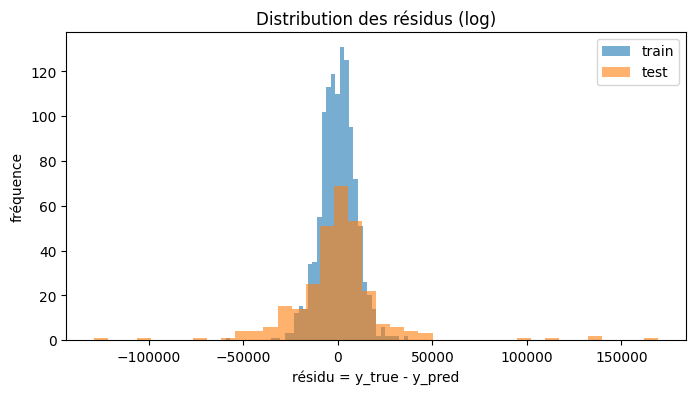

In [33]:

plt.figure(figsize=(8,4))
plt.hist(res_train, bins=40, alpha=0.6, label="train")
plt.hist(res_test,  bins=40, alpha=0.6, label="test")
plt.title("Distribution des résidus (log)")
plt.xlabel("résidu = y_true - y_pred")
plt.ylabel("fréquence")
plt.legend()
plt.show()


La distribution des résidus est globalement centrée autour de zéro, aussi bien pour l’échantillon d’entraînement que pour l’échantillon de test, ce qui indique l’absence de biais systématique du modèle.

Les résidus du jeu de test sont plus dispersés que ceux du jeu d’entraînement, ce qui est attendu puisque le modèle n’a pas été ajusté directement sur ces données. La majorité des erreurs reste néanmoins concentrée autour de zéro.

La présence de quelques valeurs extrêmes traduit des observations atypiques, sans remettre en cause la bonne capacité de généralisation du modèle.

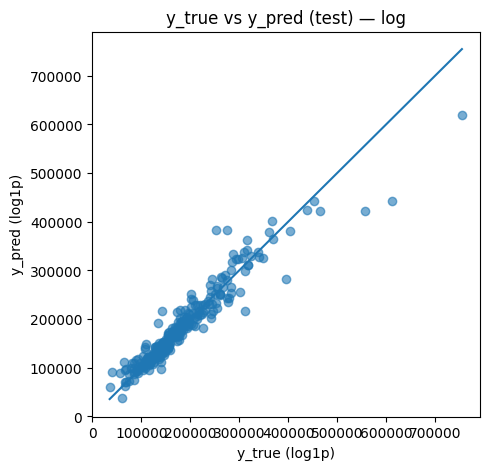

In [34]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_test, alpha=0.6)
m = min(y_test.min(), yhat_test.min())
M = max(y_test.max(), yhat_test.max())
plt.plot([m, M], [m, M])
plt.title("y_true vs y_pred (test) — log")
plt.xlabel("y_true (log1p)")
plt.ylabel("y_pred (log1p)")
plt.show()


Les points sont globalement bien alignés autour de la diagonale, ce qui montre que le modèle prédit correctement les valeurs observées sur l’échantillon test. L’absence de forte dispersion indique une bonne qualité de prédiction en échelle logarithmique, avec seulement quelques écarts pour les valeurs extrêmes.

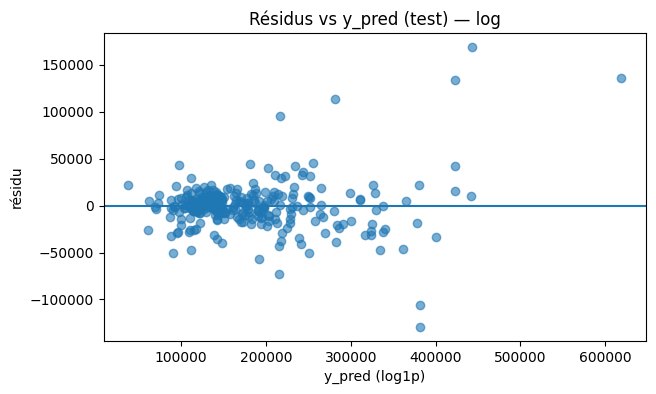

In [35]:
plt.figure(figsize=(7,4))
plt.scatter(yhat_test, res_test, alpha=0.6)
plt.axhline(0)
plt.title("Résidus vs y_pred (test) — log")
plt.xlabel("y_pred (log1p)")
plt.ylabel("résidu")
plt.show()


Les résidus sont majoritairement centrés autour de zéro et ne présentent pas de structure particulière en fonction des valeurs prédites. Cela suggère l’absence de biais systématique et une variance des erreurs relativement stable sur l’ensemble des prédictions.

CONCLUSION
Les graphiques confirment que le modèle Gradient Boosting capture correctement la relation entre les variables explicatives et le prix des maisons, avec des erreurs globalement faibles et non structurées.

In [36]:
# Vérifier que yhat_test est défini, sinon le calculer avec le meilleur modèle
if 'yhat_test' not in globals():
    print("ATTENTION: yhat_test n'est pas défini. Calcul des prédictions avec best_gbr...")
    if 'best_gbr' in globals() and 'X_test' in globals():
        yhat_test = best_gbr.predict(X_test)
        print("✓ Prédictions calculées avec best_gbr")
    else:
        raise NameError("yhat_test n'est pas défini et best_gbr/X_test ne sont pas disponibles. Exécutez d'abord la cellule qui entraîne le modèle.")

# Vérifier que y_test est défini
if 'y_test' not in globals():
    raise NameError("y_test n'est pas défini. Exécutez d'abord la cellule de split train/test.")

# y_test et yhat_test sont déjà en valeurs réelles (dollars), pas besoin de transformation
y_test_price  = np.array(y_test).copy()
y_pred_price  = np.array(yhat_test).copy()

# Vérifier les valeurs
print(f"y_test_price - min: {y_test_price.min():.2f}, max: {y_test_price.max():.2f}, mean: {y_test_price.mean():.2f}")
print(f"y_pred_price - min: {y_pred_price.min():.2f}, max: {y_pred_price.max():.2f}, mean: {y_pred_price.mean():.2f}")

abs_err_price = np.abs(y_test_price - y_pred_price)

# Filtrer les valeurs NaN ou infinies
mask = np.isfinite(y_test_price) & np.isfinite(y_pred_price) & np.isfinite(abs_err_price)
y_test_price = y_test_price[mask]
y_pred_price = y_pred_price[mask]
abs_err_price = abs_err_price[mask]

print(f"\nNombre de valeurs valides: {len(abs_err_price)} / {len(mask)}")

print("\nErreur absolue en $ (test)")
print("MAE $ :", abs_err_price.mean())
print("Med $ :", np.median(abs_err_price))
print("95%  :", np.percentile(abs_err_price, 95))


y_test_price - min: 35311.00, max: 755000.00, mean: 178839.81
y_pred_price - min: 37749.42, max: 618865.11, mean: 179066.02

Nombre de valeurs valides: 292 / 292

Erreur absolue en $ (test)
MAE $ : 15287.04643770881
Med $ : 8743.853952638601
95%  : 44632.487101081635


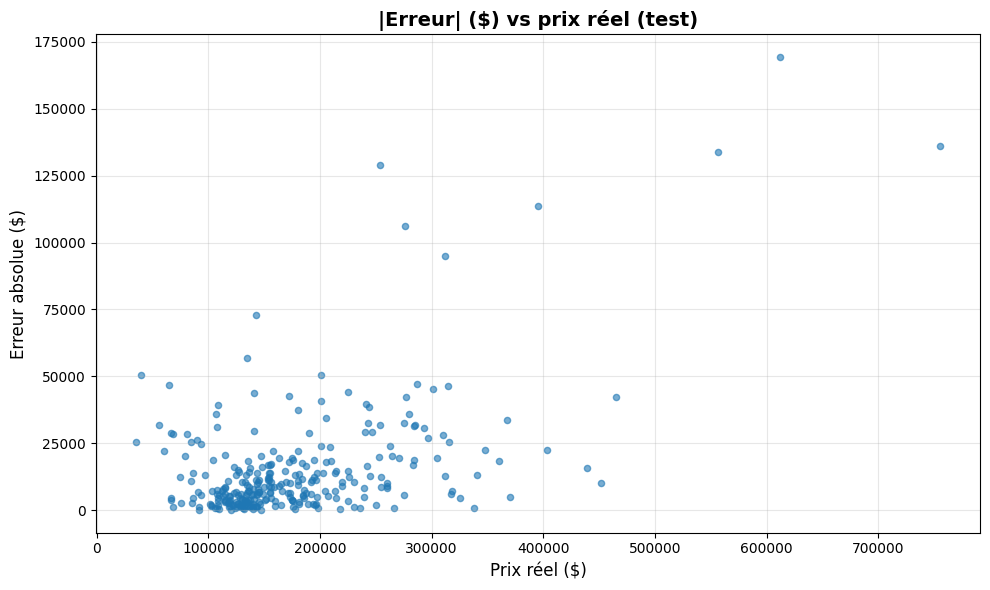


Graphique affiché avec 292 points de données


In [37]:
# Vérifier que les variables existent
if 'y_test_price' not in globals() or 'abs_err_price' not in globals():
    raise NameError("y_test_price ou abs_err_price ne sont pas définis. Exécutez d'abord la cellule précédente.")

# Vérifier qu'il y a des données à afficher
if len(y_test_price) == 0 or len(abs_err_price) == 0:
    print("ATTENTION: Aucune donnée valide à afficher. Vérifiez que y_test et yhat_test contiennent des valeurs valides.")
else:
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_price, abs_err_price, alpha=0.6, s=20)
    plt.title("|Erreur| ($) vs prix réel (test)", fontsize=14, fontweight='bold')
    plt.xlabel("Prix réel ($)", fontsize=12)
    plt.ylabel("Erreur absolue ($)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nGraphique affiché avec {len(y_test_price)} points de données")



Le graphique montre que l’erreur absolue tend à augmenter avec le prix du logement. Le modèle est donc plus précis pour les biens de prix moyen, tandis que les logements très chers présentent des erreurs plus importantes

In [38]:
# Récupérer le preprocessor et le modèle depuis le pipeline
prep = best_gbr.named_steps["preprocess"]
model = best_gbr.named_steps["model"]

# Noms des variables après transformation
feature_names = prep.get_feature_names_out()

importances = model.feature_importances_
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)


,feature,importance
40,num__TotalSF,0.413385
3,num__OverallQual,0.275093
13,num__2ndFlrSF,0.026837
53,ord__KitchenQual,0.025621
8,num__BsmtFinSF1,0.021278
37,num__HouseAge,0.019745
25,num__GarageCars,0.018946
42,num__TotalBath,0.018075
47,ord__BsmtQual,0.016937
2,num__LotArea,0.014469


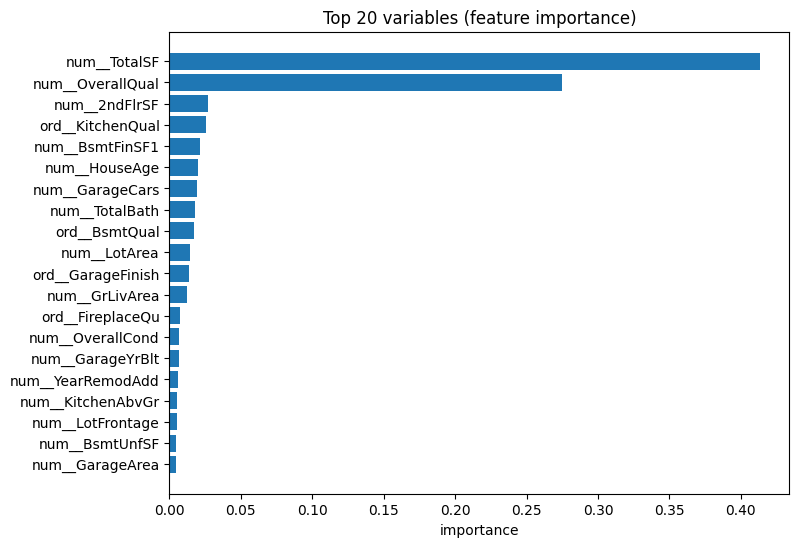

In [39]:
topk = 20
fi_top = fi.head(topk).iloc[::-1]  # inversé pour joli plot

plt.figure(figsize=(8,6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title(f"Top {topk} variables (feature importance)")
plt.xlabel("importance")
plt.ylabel("")
plt.show()


In [40]:
def group_feature_name(feat):
    # ex: "nom__Neighborhood_NridgHt" -> "Neighborhood"
    # ex: "num__TotalSF" -> "TotalSF"
    s = feat.split("__", 1)[-1]  # enlève num__/ord__/nom__
    return s.split("_", 1)[0]    # garde la racine avant la 1ère underscore

fi["group"] = fi["feature"].apply(group_feature_name)
fi_group = fi.groupby("group")["importance"].sum().sort_values(ascending=False).reset_index()

fi_group.head(15)


,group,importance
0,TotalSF,0.413385
1,OverallQual,0.275093
2,2ndFlrSF,0.026837
3,KitchenQual,0.025621
4,BsmtFinSF1,0.021278
5,HouseAge,0.019745
6,GarageCars,0.018946
7,TotalBath,0.018075
8,BsmtQual,0.016937
9,LotArea,0.014469


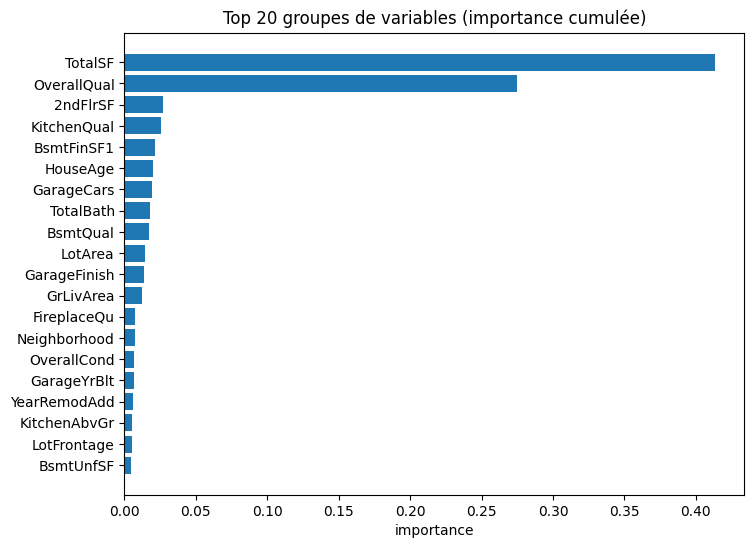

In [42]:
topk = 20
g = fi_group.head(topk).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(g["group"], g["importance"])
plt.title(f"Top {topk} groupes de variables (importance cumulée)")
plt.xlabel("importance")
plt.ylabel("")
plt.show()


Le prix des maisons est principalement expliqué par la surface, la qualité globale, puis les équipements clés (salles de bain, cuisine, garage). Les caractéristiques structurelles dominent largement les variables secondaires.

In [43]:


print("="*80)
print("SAUVEGARDE DES RÉSULTATS + SUBMISSIONS KAGGLE (CHEMIN FIXE)")
print("="*80)

# ============================================================
# 1) CHEMIN OUTPUT 
# ============================================================


# Point de départ = dossier où tourne le notebook (ici .../notebooks)
cwd = Path.cwd()

# On remonte jusqu'à trouver un dossier qui contient "output"
PROJECT_ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / "output").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(f"Impossible de trouver un dossier 'output' en remontant depuis: {cwd}")

OUTPUT_ROOT = PROJECT_ROOT / "output"

# Fonction helper pour convertir un chemin en chemin relatif
def get_relative_path(path):
    """Convertit un chemin Path en chemin relatif par rapport au PROJECT_ROOT"""
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        # Si le chemin n'est pas relatif au PROJECT_ROOT, retourner le chemin tel quel
        return str(path)

print("CWD         =", get_relative_path(cwd))
print("PROJECT_ROOT=", get_relative_path(PROJECT_ROOT))
print("OUTPUT_ROOT =", get_relative_path(OUTPUT_ROOT))


MODELS_DIR = OUTPUT_ROOT / "models"
PRED_DIR   = OUTPUT_ROOT / "predictions"
ANAL_DIR   = OUTPUT_ROOT / "analysis"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)
ANAL_DIR.mkdir(parents=True, exist_ok=True)

print(" Working directory =", get_relative_path(Path(os.getcwd())))
print(" OUTPUT_ROOT =", get_relative_path(OUTPUT_ROOT))

# ============================================================
# 2) VÉRIFIER test_df (Kaggle test)
# ============================================================
if "test_df" not in globals():
    raise NameError(" Je ne trouve pas `test_df` (le test Kaggle). Assure-toi qu'il existe dans le notebook.")

kaggle_test_raw = test_df.copy()
print(f"Kaggle test trouvé : test_df shape = {kaggle_test_raw.shape}")

# ============================================================
# 3) FEATURE ENGINEERING (recréer les colonnes attendues)
# ============================================================
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def col(name, default=np.nan):
        return df[name] if name in df.columns else default

    # HouseAge
    if "YrSold" in df.columns and "YearBuilt" in df.columns:
        df["HouseAge"] = col("YrSold") - col("YearBuilt")
    else:
        df["HouseAge"] = np.nan

    # RemodAge
    if "YrSold" in df.columns and "YearRemodAdd" in df.columns:
        df["RemodAge"] = col("YrSold") - col("YearRemodAdd")
    else:
        df["RemodAge"] = np.nan

    # GarageAge
    if "YrSold" in df.columns and "GarageYrBlt" in df.columns:
        df["GarageAge"] = col("YrSold") - col("GarageYrBlt")
    else:
        df["GarageAge"] = np.nan

    # TotalSF
    df["TotalSF"] = (
        pd.to_numeric(col("TotalBsmtSF", 0), errors="coerce").fillna(0)
        + pd.to_numeric(col("1stFlrSF", 0), errors="coerce").fillna(0)
        + pd.to_numeric(col("2ndFlrSF", 0), errors="coerce").fillna(0)
    )

    # TotalBath
    df["TotalBath"] = (
        pd.to_numeric(col("FullBath", 0), errors="coerce").fillna(0)
        + 0.5 * pd.to_numeric(col("HalfBath", 0), errors="coerce").fillna(0)
        + pd.to_numeric(col("BsmtFullBath", 0), errors="coerce").fillna(0)
        + 0.5 * pd.to_numeric(col("BsmtHalfBath", 0), errors="coerce").fillna(0)
    )

    # TotalPorchSF
    porch_cols = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]
    total_porch = 0
    for pc in porch_cols:
        total_porch += pd.to_numeric(col(pc, 0), errors="coerce").fillna(0)
    df["TotalPorchSF"] = total_porch

    return df

kaggle_test = add_engineered_features(kaggle_test_raw)

# ============================================================
# 4) DÉTECTER TES MODÈLES (best_*)
# ============================================================
def pick_first_existing(candidates):
    for c in candidates:
        if c in globals() and globals()[c] is not None:
            return globals()[c], c
    return None, None

models_dict = {}

ridge_obj, _ = pick_first_existing(["best_ridge", "best_ridge_model", "ridge_best", "best_ridge_estimator"])
if ridge_obj is not None: models_dict["Ridge"] = ridge_obj

lasso_obj, _ = pick_first_existing(["best_lasso", "best_lasso_model", "lasso_best", "best_lasso_estimator"])
if lasso_obj is not None: models_dict["Lasso"] = lasso_obj

rf_obj, _ = pick_first_existing(["best_rf", "best_rf_model", "best_randomforest", "best_random_forest"])
if rf_obj is not None: models_dict["RandomForest"] = rf_obj

gbr_obj, _ = pick_first_existing(["best_gbr", "best_gbr_model", "best_gradientboosting", "best_gradientboosting_model"])
if gbr_obj is not None: models_dict["GradientBoosting"] = gbr_obj

lgb_obj, _ = pick_first_existing(["best_lgb", "best_lgb_model", "best_lightgbm", "best_lightgbm_model"])
if lgb_obj is not None: models_dict["LightGBM"] = lgb_obj

xgb_obj, _ = pick_first_existing(["best_xgb", "best_xgb_model", "best_xgboost", "best_xgboost_model"])
if xgb_obj is not None: models_dict["XGBoost"] = xgb_obj

print("Modèles détectés :", list(models_dict.keys()))
if len(models_dict) == 0:
    raise NameError(" Aucun modèle détecté. Vérifie que tes variables best_* existent (best_gbr, best_ridge, etc.).")

# ============================================================
# 5) SPLIT TEST (validation) : sauver y_test_log et prédictions
# ============================================================
def rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

has_split = ("X_test" in globals()) and ("y_test" in globals())

metrics_rows = []
if has_split:
    y_test_log = np.array(y_test)
    np.save(MODELS_DIR / "y_test_log.npy", y_test_log)
    print(f"y_test_log sauvegardé : {get_relative_path(MODELS_DIR / 'y_test_log.npy')}")

    for name, model in models_dict.items():
        yhat = model.predict(X_test)
        np.save(MODELS_DIR / f"y_pred_{name.lower()}_log.npy", np.array(yhat))
        r = rmse(y_test, yhat)
        metrics_rows.append({"model": name, "rmse_test": r})
        print(f"y_pred_{name.lower()}_log.npy sauvegardé | RMSE(test)={r:.6f}")

    metrics_df = pd.DataFrame(metrics_rows).sort_values("rmse_test").reset_index(drop=True)
    metrics_df.to_csv(ANAL_DIR / "rmse_test_by_model.csv", index=False)
    best_name = metrics_df.loc[0, "model"]
    best_rmse = metrics_df.loc[0, "rmse_test"]
    print(f"\nMEILLEUR MODÈLE (split test) = {best_name} | RMSE(test) = {best_rmse:.6f}\n")
else:
    print("ATTENTION: X_test / y_test introuvables : je ne calcule pas RMSE(test) ni y_pred_* sur split.")
    metrics_df = None

# ============================================================
# 6) SAUVEGARDE DES MODÈLES (.joblib)
# ============================================================
for name, model in models_dict.items():
    path = MODELS_DIR / f"best_{name.lower()}.joblib"
    joblib.dump(model, path)
    print(f"Modèle sauvegardé : {get_relative_path(path)}")

# ============================================================
# 7) SUBMISSIONS KAGGLE POUR TOUS LES MODÈLES
# ============================================================
if "Id" not in kaggle_test.columns:
    raise ValueError(" La colonne 'Id' est absente de test_df, impossible de faire une soumission Kaggle.")

for name, model in models_dict.items():
    pred_log = model.predict(kaggle_test)
    pred_price = np.expm1(pred_log)
    sub = pd.DataFrame({"Id": kaggle_test["Id"].values, "SalePrice": pred_price})
    out_path = PRED_DIR / f"kaggle_submission_{name.lower()}.csv"
    sub.to_csv(out_path, index=False)
    print(f"Soumission : {get_relative_path(out_path)} | mean price=${pred_price.mean():,.0f}")

# ============================================================
# 8) FEATURE IMPORTANCE (si possible)
# ============================================================
def export_feature_importance(model, model_name):
    feat_names = None
    step_model = model

    try:
        if hasattr(model, "named_steps"):
            # step preprocess possible
            for pre_name in ["preprocess", "preprocessor", "prep", "preprocess_no_scale"]:
                if pre_name in model.named_steps:
                    pre = model.named_steps[pre_name]
                    try:
                        feat_names = pre.get_feature_names_out()
                    except Exception:
                        feat_names = None
                    break
            # step model
            for mname in ["model", "estimator", "regressor"]:
                if mname in model.named_steps:
                    step_model = model.named_steps[mname]
                    break
    except Exception:
        pass

    # arbres / boosting
    if hasattr(step_model, "feature_importances_"):
        imps = step_model.feature_importances_
        if feat_names is None:
            feat_names = [f"feature_{i}" for i in range(len(imps))]
        df = pd.DataFrame({"feature": feat_names, "importance": imps}).sort_values("importance", ascending=False)
        df.to_csv(ANAL_DIR / f"feature_importance_{model_name.lower()}.csv", index=False)
        print(f"Feature importance : {get_relative_path(ANAL_DIR / f'feature_importance_{model_name.lower()}.csv')}")
        return

    # modèles linéaires
    if hasattr(step_model, "coef_"):
        coefs = step_model.coef_
        if feat_names is None:
            feat_names = [f"feature_{i}" for i in range(len(coefs))]
        df = pd.DataFrame({"feature": feat_names, "importance": np.abs(coefs), "coefficient": coefs}).sort_values("importance", ascending=False)
        df.to_csv(ANAL_DIR / f"feature_importance_{model_name.lower()}.csv", index=False)
        print(f"Coefs importance : {get_relative_path(ANAL_DIR / f'feature_importance_{model_name.lower()}.csv')}")
        return

    print(f"ATTENTION: Pas d'importance exploitable pour {model_name} (ni coef_ ni feature_importances_).")

for name, model in models_dict.items():
    export_feature_importance(model, name)

# ============================================================
# 9) LISTING FINAL DES FICHIERS CRÉÉS
# ============================================================
print("\n" + "="*80)
print("FICHIERS CRÉÉS DANS :", get_relative_path(OUTPUT_ROOT))
print("="*80)
for folder in [MODELS_DIR, PRED_DIR, ANAL_DIR]:
    files = list(folder.glob("*"))
    print(f"\n{get_relative_path(folder)}  -> {len(files)} fichier(s)")
    for f in files[:40]:
        print("  -", f.name)
    if len(files) > 40:
        print("  ...")


SAUVEGARDE DES RÉSULTATS + SUBMISSIONS KAGGLE (CHEMIN FIXE)
CWD         = .
PROJECT_ROOT= .
OUTPUT_ROOT = output
 Working directory = .
 OUTPUT_ROOT = output
Kaggle test trouvé : test_df shape = (1459, 83)
Modèles détectés : ['Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost']
y_test_log sauvegardé : output\models\y_test_log.npy
y_pred_ridge_log.npy sauvegardé | RMSE(test)=23032.385683
y_pred_lasso_log.npy sauvegardé | RMSE(test)=30242.445903
y_pred_randomforest_log.npy sauvegardé | RMSE(test)=28972.268230
y_pred_gradientboosting_log.npy sauvegardé | RMSE(test)=26368.027356
y_pred_lightgbm_log.npy sauvegardé | RMSE(test)=29229.941135
y_pred_xgboost_log.npy sauvegardé | RMSE(test)=24695.742986


C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



MEILLEUR MODÈLE (split test) = Ridge | RMSE(test) = 23032.385683

Modèle sauvegardé : output\models\best_ridge.joblib
Modèle sauvegardé : output\models\best_lasso.joblib
Modèle sauvegardé : output\models\best_randomforest.joblib
Modèle sauvegardé : output\models\best_gradientboosting.joblib
Modèle sauvegardé : output\models\best_lightgbm.joblib
Modèle sauvegardé : output\models\best_xgboost.joblib


C:\Users\pc\AppData\Local\Temp\ipykernel_18420\2812905142.py:193: RuntimeWarning: overflow encountered in expm1
  pred_price = np.expm1(pred_log)


Soumission : output\predictions\kaggle_submission_ridge.csv | mean price=$inf


...

Soumission : output\predictions\kaggle_submission_lasso.csv | mean price=$inf


C:\Users\pc\AppData\Local\Temp\ipykernel_18420\2812905142.py:193: RuntimeWarning: overflow encountered in expm1
  pred_price = np.expm1(pred_log)
C:\Users\pc\AppData\Local\Temp\ipykernel_18420\2812905142.py:193: RuntimeWarning: overflow encountered in expm1
  pred_price = np.expm1(pred_log)
C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Soumission : output\predictions\kaggle_submission_randomforest.csv | mean price=$inf
Soumission : output\predictions\kaggle_submission_gradientboosting.csv | mean price=$inf


C:\Users\pc\AppData\Local\Temp\ipykernel_18420\2812905142.py:193: RuntimeWarning: overflow encountered in expm1
  pred_price = np.expm1(pred_log)
C:\Users\pc\AppData\Local\Temp\ipykernel_18420\2812905142.py:193: RuntimeWarning: overflow encountered in expm1
  pred_price = np.expm1(pred_log)


Soumission : output\predictions\kaggle_submission_lightgbm.csv | mean price=$inf
Soumission : output\predictions\kaggle_submission_xgboost.csv | mean price=$inf
ATTENTION: Pas d'importance exploitable pour Ridge (ni coef_ ni feature_importances_).
Coefs importance : output\analysis\feature_importance_lasso.csv
Feature importance : output\analysis\feature_importance_randomforest.csv
Feature importance : output\analysis\feature_importance_gradientboosting.csv
Feature importance : output\analysis\feature_importance_lightgbm.csv
Feature importance : output\analysis\feature_importance_xgboost.csv

FICHIERS CRÉÉS DANS : output

output\models  -> 23 fichier(s)
  - best_gradientboosting.joblib
  - best_lasso.joblib
  - best_lightgbm.joblib
  - best_randomforest.joblib
  - best_ridge.joblib
  - best_xgboost.joblib
  - model_elasticnet.joblib
  - model_final.joblib
  - model_gbr.joblib
  - model_lasso.joblib
  - model_lightgbm.joblib
  - model_linearregression.joblib
  - model_metadata.joblib
  